In [4]:
import dgl
import networkx as nx
import matplotlib.pyplot as plt
import torch
import random

def visualize_dgl_graph(g, 
                       sample_size=None,
                       node_labels=True,
                       with_text=True,
                       figure_size=(12, 8),
                       seed=42):
    """
    Visualize a DGL graph or a sampled subset of it.
    
    Parameters:
    -----------
    g : DGLGraph
        The input DGL graph
    sample_size : int, optional
        Number of nodes to sample for visualization. If None, visualizes entire graph
    node_labels : bool, optional
        Whether to show node IDs on the visualization
    with_text : bool, optional
        Whether to show text features (if available) in the visualization
    figure_size : tuple, optional
        Size of the matplotlib figure
    seed : int, optional
        Random seed for consistent sampling
    
    Returns:
    --------
    None (displays the plot)
    """
    # Set random seed for reproducibility
    random.seed(seed)
    torch.manual_seed(seed)
    
    # Sample nodes if sample_size is specified
    if sample_size is not None and sample_size < g.number_of_nodes():
        sampled_nodes = torch.tensor(random.sample(range(g.number_of_nodes()), sample_size))
        g = dgl.node_subgraph(g, sampled_nodes)
    
    # Convert to networkx for visualization
    nx_g = g.to_networkx(node_attrs=['feat'] if 'feat' in g.ndata else None)
    
    # Create figure
    plt.figure(figsize=figure_size)
    
    # Get layout
    pos = nx.spring_layout(nx_g)
    
    # Draw the graph
    nx.draw(nx_g, pos, 
           node_color='lightblue',
           node_size=500,
           with_labels=node_labels,
           font_size=8,
           font_weight='bold',
           edge_color='gray',
           arrows=True)
    
    # Add text features if available and requested
    if with_text and 'feat' in g.ndata:
        text_labels = {}
        for node in nx_g.nodes():
            if 'feat' in nx_g.nodes[node]:
                # Assuming text features are stored in node features
                # You might need to adjust this based on your actual feature format
                text = nx_g.nodes[node]['feat']
                if isinstance(text, torch.Tensor):
                    text = text.tolist()
                text_labels[node] = str(text)[:10] + '...'  # Truncate long text
        
        nx.draw_networkx_labels(nx_g, pos, text_labels, font_size=6)
    
    plt.title(f"Graph Visualization (Nodes: {g.number_of_nodes()}, Edges: {g.number_of_edges()})")
    plt.axis('off')
    plt.show()

def load_and_visualize_sample(graph_path, sample_size=100):
    """
    Load a DGL graph from a file and visualize a sample of it.
    
    Parameters:
    -----------
    graph_path : str
        Path to the .bin file containing the DGL graph
    sample_size : int
        Number of nodes to sample for visualization
        
    Returns:
    --------
    None (displays the plot)
    """
    # Load the graph
    g = dgl.load_graphs(graph_path)[0][2]
    
    print(f"Loaded graph with {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")
    print("Node features:", g.ndata.keys())
    print("Edge features:", g.edata.keys())
    
    # Visualize a sample
    visualize_dgl_graph(g, sample_size=sample_size)

Loaded graph with 86 nodes and 452 edges
Node features: dict_keys(['w'])
Edge features: dict_keys(['w'])


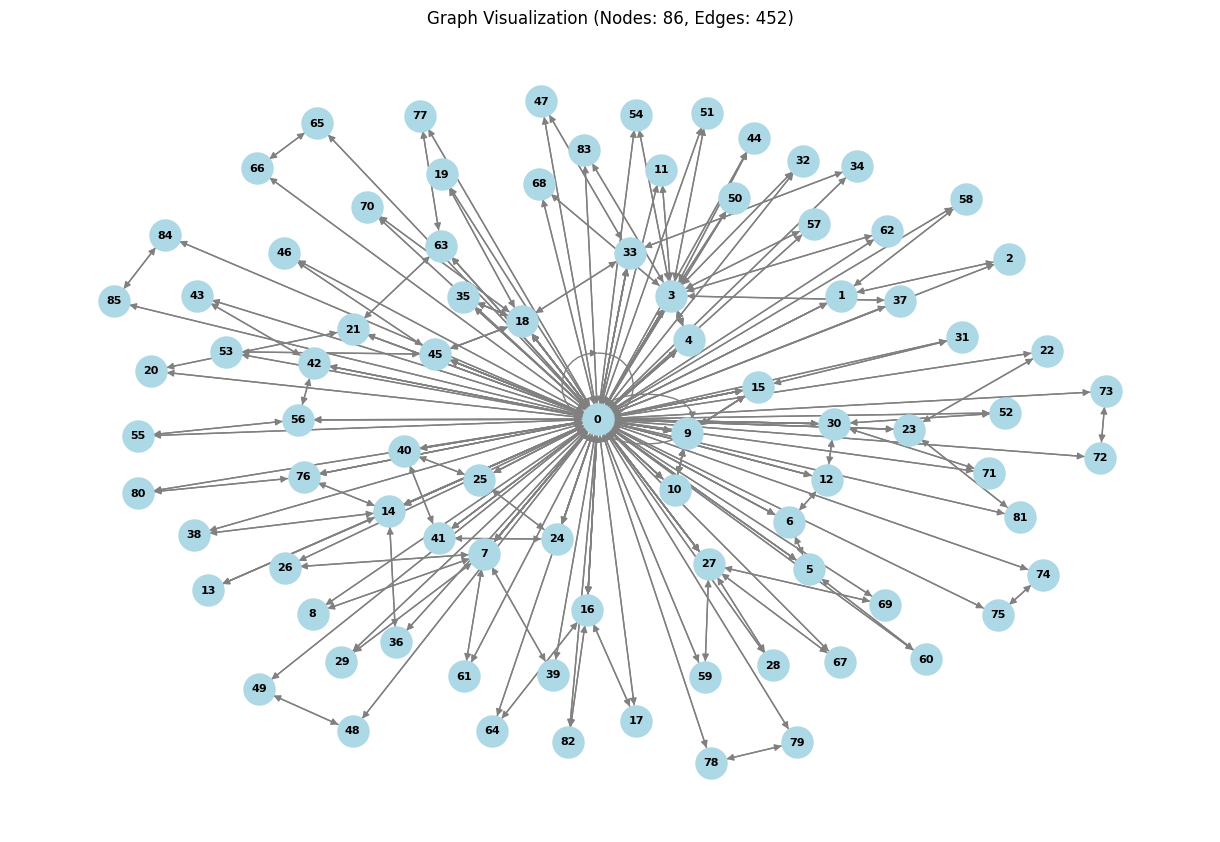

In [5]:
load_and_visualize_sample('./graph/graph_bin/bidirec_train_issue.bin', sample_size=1442)